# 03: Python-based Preprocessing Routine Reproducibility

## Dataset
- [GSE223065](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE223065)

---
## 0. Execution Environment Summary

In [1]:
%%bash
bash .rep_exe_env_short.sh

=== Execution Start ===


Timestamp (UTC): 2026-09-29T20:16:32Z


Hostname:        acrest-gpu1


OS:              Ubuntu 22.04.5 LTS


---
## 1. Data Download

In [2]:
%%bash

DATA_DIR="./data"
FILE_NAME="gbm"
SRC="https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSE223065&format=file"

mkdir -p "$DATA_DIR/$FILE_NAME"

if compgen -G "$DATA_DIR/$FILE_NAME/*.gz" > /dev/null; then
    echo "$FILE_NAME data already exists. Skipping download."
else
    curl -fL \
        -o "$DATA_DIR/$FILE_NAME/data.tar" \
        "$SRC"

    tar -xvf \
        "$DATA_DIR/$FILE_NAME/data.tar" \
        -C "$DATA_DIR/$FILE_NAME"

    rm -f "$DATA_DIR/$FILE_NAME/data.tar"
fi

  % Total    % Received % Xferd  Average Speed  Time    Time    Time   Current
                     

            Dload  Upload  Total   Spent   Left   Speed
  0      0   0      0   0      0      0    

  0                              0

  0      0   0      0

   0      0      0      0                              0


...

GSM6939137_HFC3_features.tsv.gz


GSM6939137_HFC3_matrix.mtx.gz


GSM6939138_LFC3_barcodes.tsv.gz


GSM6939138_LFC3_features.tsv.gz


GSM6939138_LFC3_matrix.mtx.gz


---
## 2. QC
### 2-1. Thresholding QC metrics

In [3]:
import glob
import math
import os

import anndata as ad
import matplotlib.pyplot as plt
import scanpy as sc

from basalcelldemo_tools.anndata import transfer_embedding_info
from basalcelldemo_tools.preferences import (
    DATA_DIR,
    OUTPUT_DIR,
    kwarg_savefig,
)

ENV_SUFFIX = os.environ["ENV_SUFFIX"]

In [4]:
mtx_files = glob.glob(str(DATA_DIR / "gbm/*_matrix.mtx.gz"))
mtx_prefix = [v.split("/")[-1].split("matrix.mtx")[0] for v in mtx_files]

datasets = {}

for prefix in mtx_prefix:
    key = prefix.split("_")[1]
    datasets[key] = sc.read_10x_mtx(DATA_DIR / "gbm", prefix=prefix)

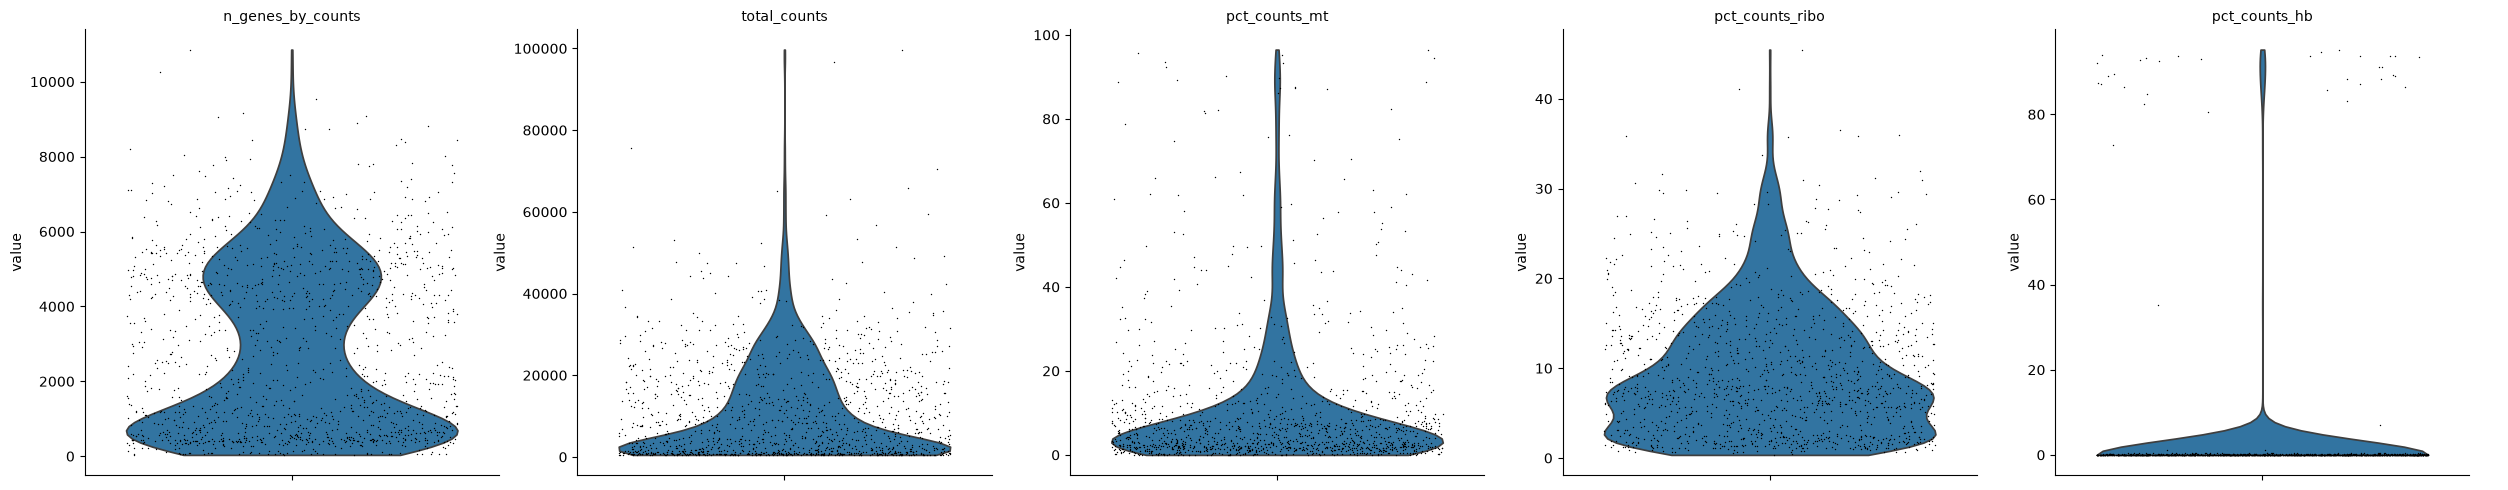

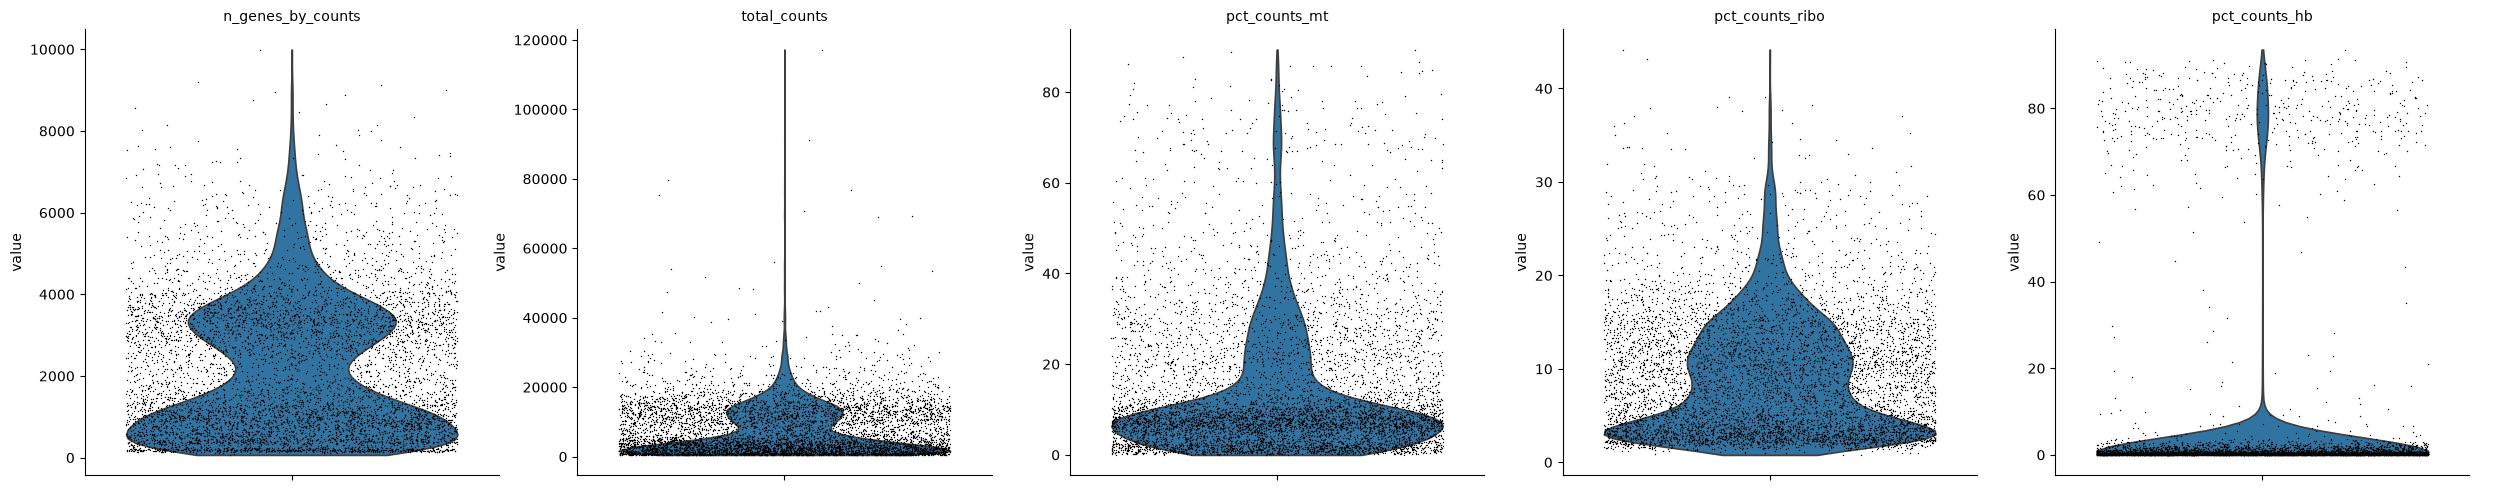

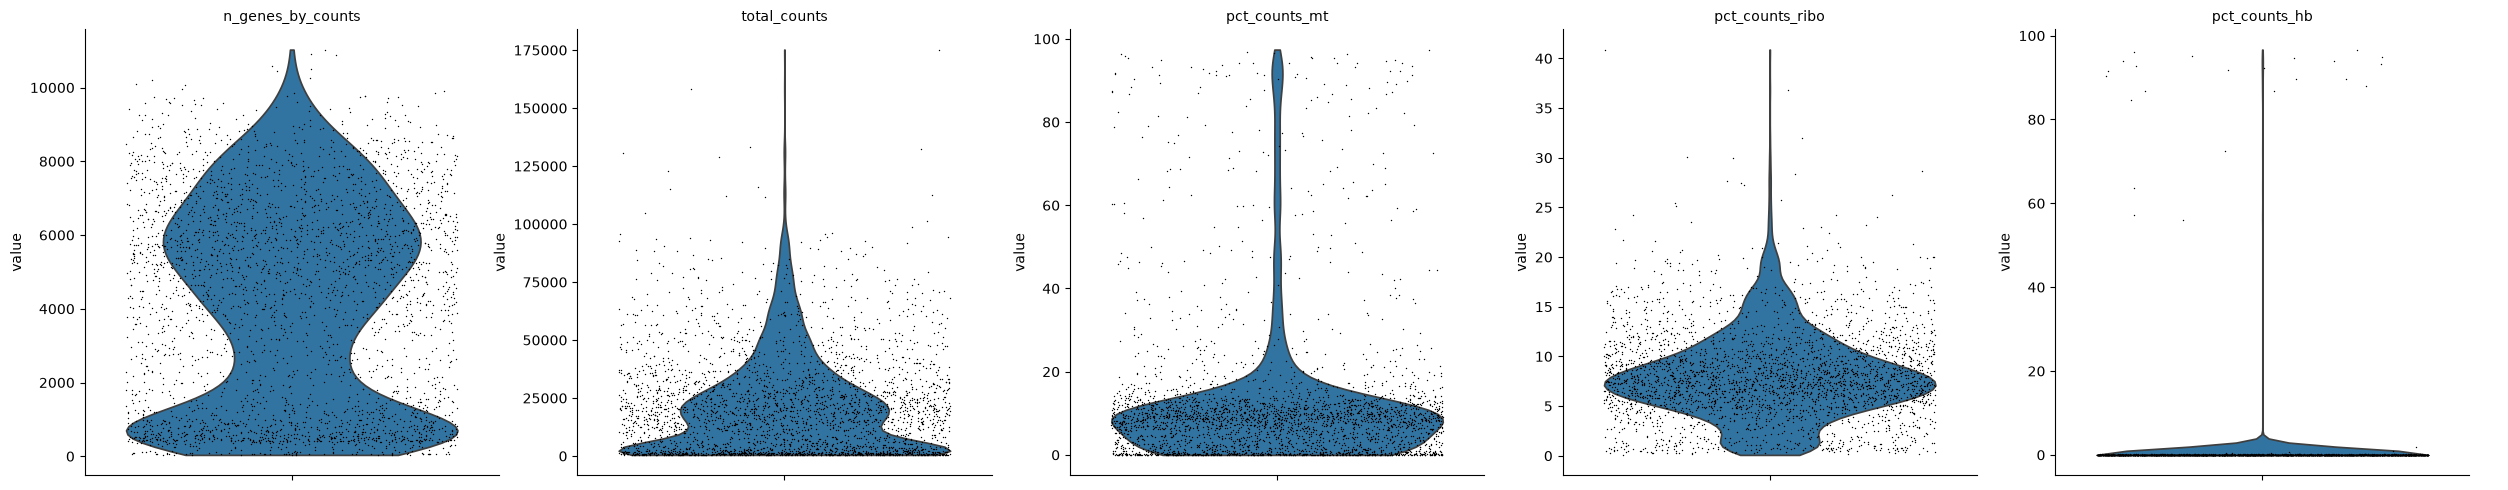

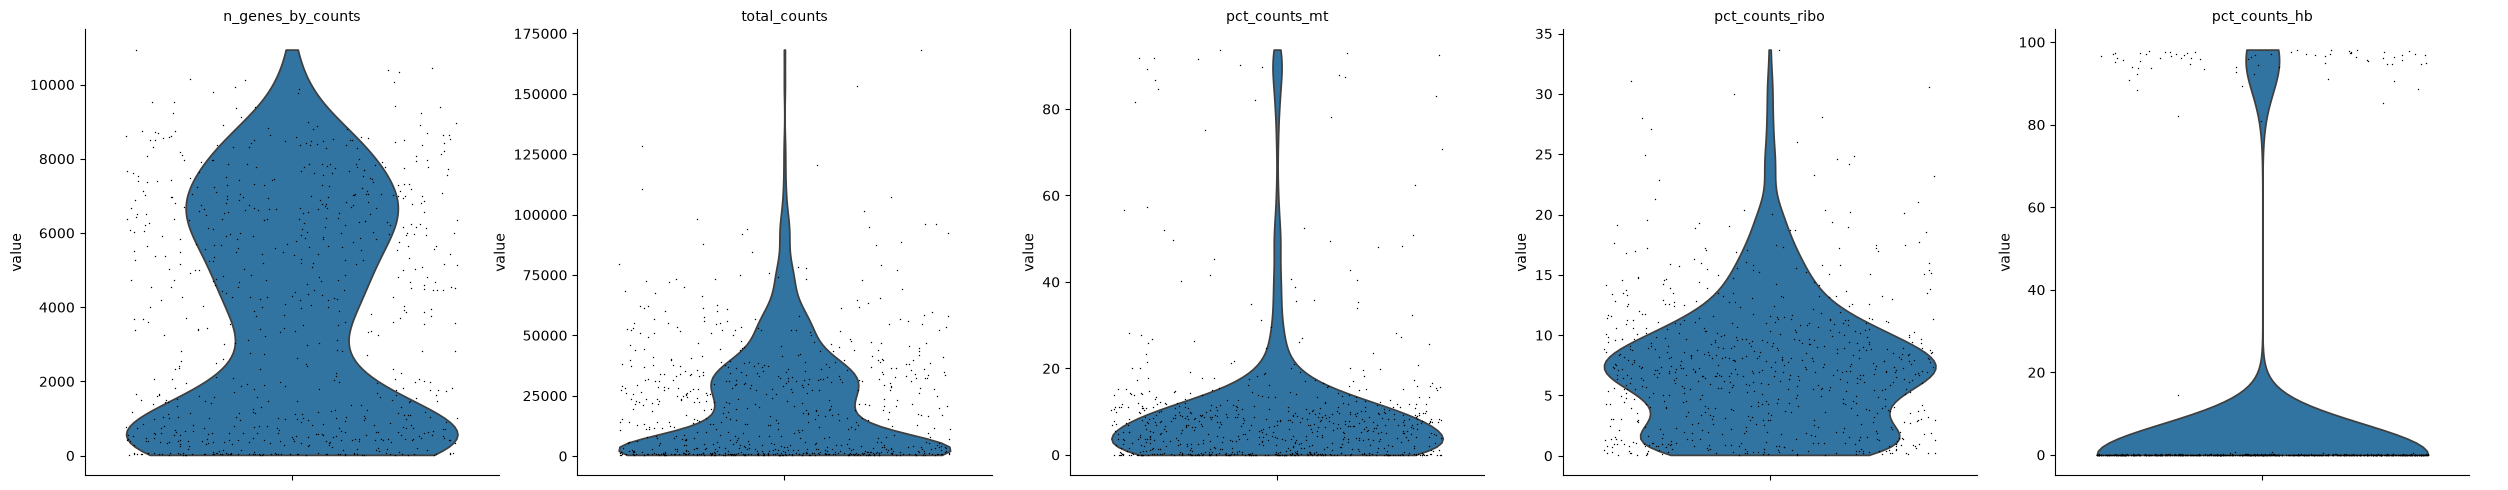

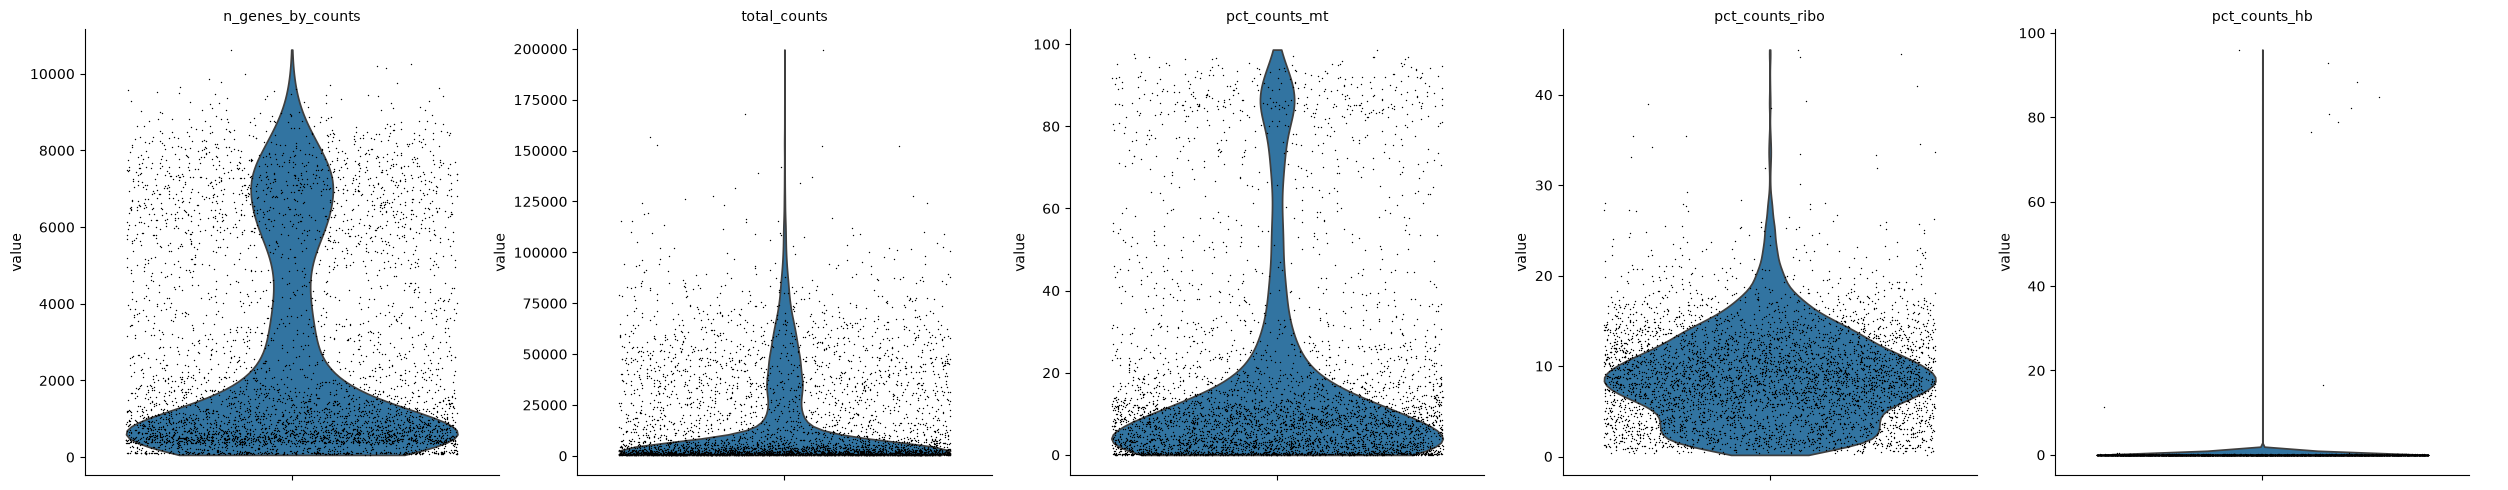

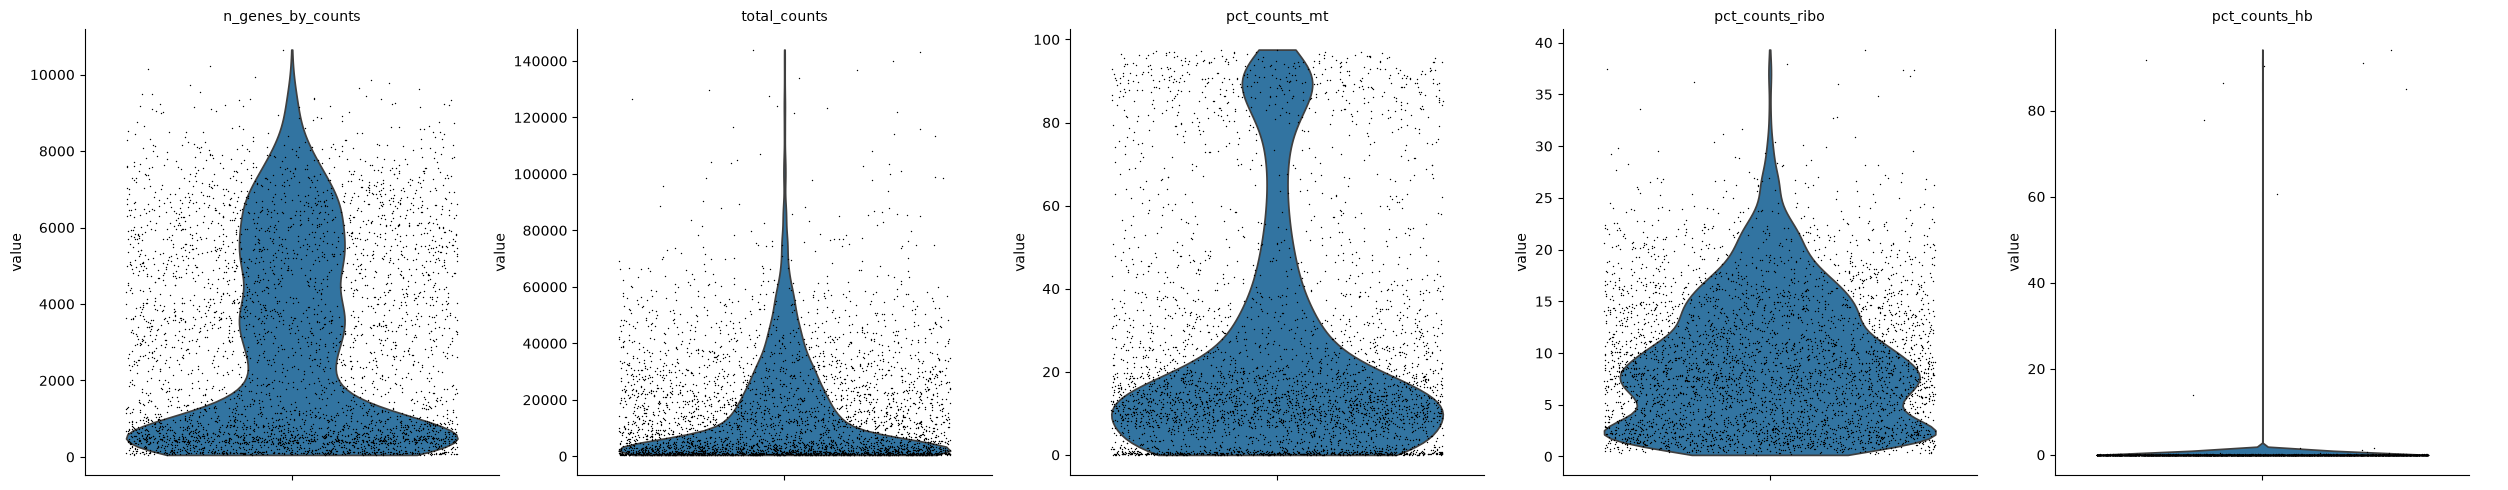

In [5]:
for k, _adata in datasets.items():
    _adata.var["mt"] = _adata.var_names.str.startswith("MT-")
    _adata.var["ribo"] = _adata.var_names.str.startswith(("RPS", "RPL"))
    _adata.var["hb"] = _adata.var_names.str.contains("^HB[^(P)]")
    sc.pp.calculate_qc_metrics(
        _adata, qc_vars=["mt", "ribo", "hb"], inplace=True, log1p=True
    )
    sc.pl.violin(
        _adata,
        [
            "n_genes_by_counts",
            "total_counts",
            "pct_counts_mt",
            "pct_counts_ribo",
            "pct_counts_hb",
        ],
        jitter=0.4,
        multi_panel=True,
    )
    datasets[k] = _adata[_adata.obs.pct_counts_mt < 25, :].copy()

### 2-2. Doublet Detection

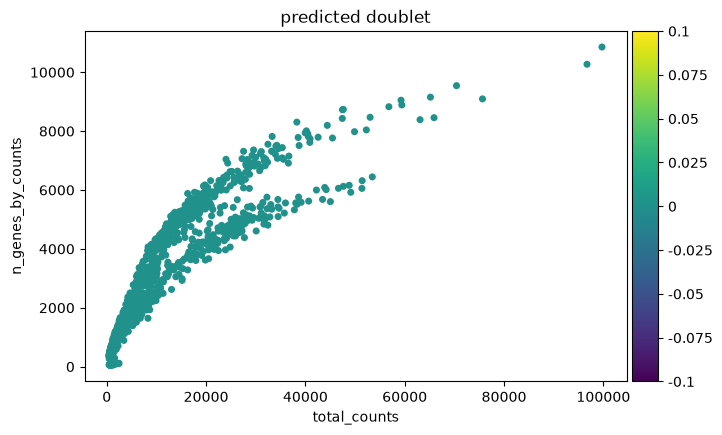

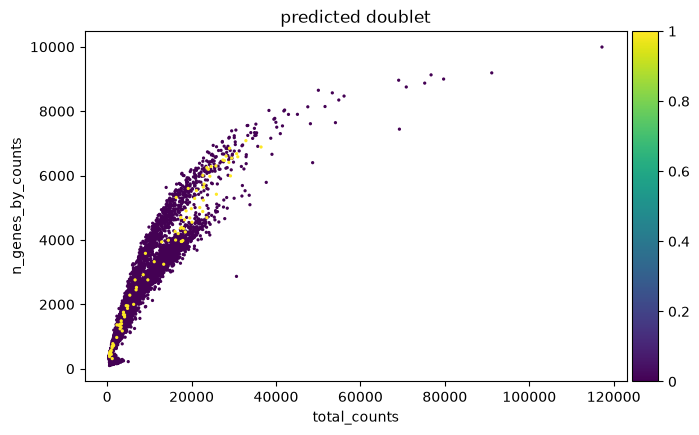

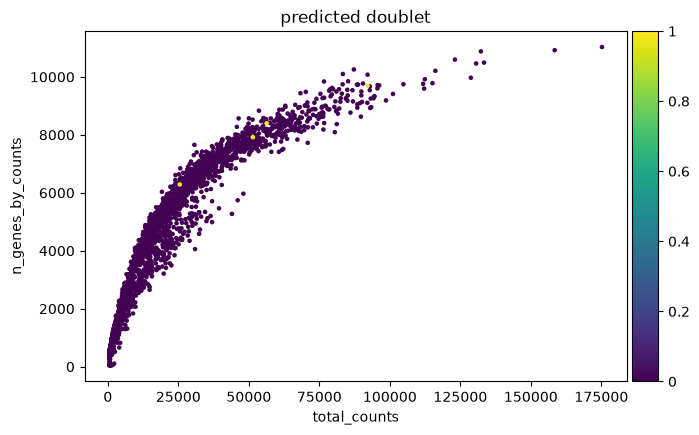

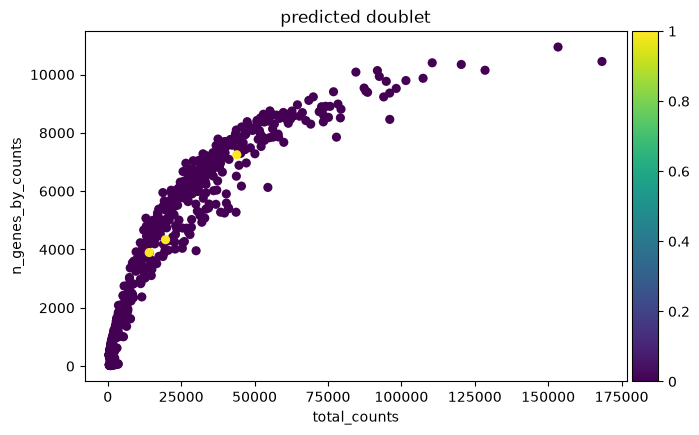

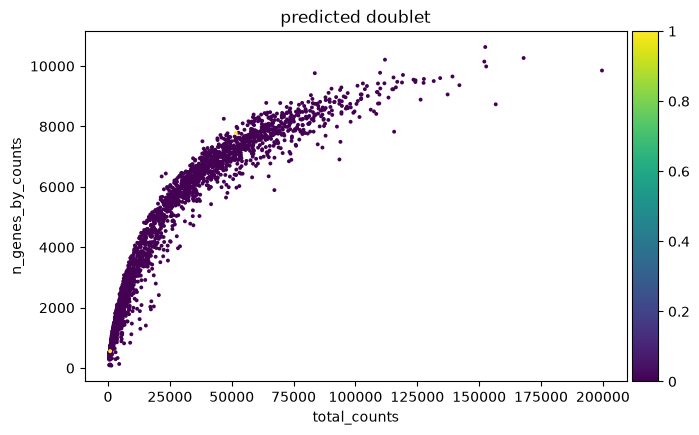

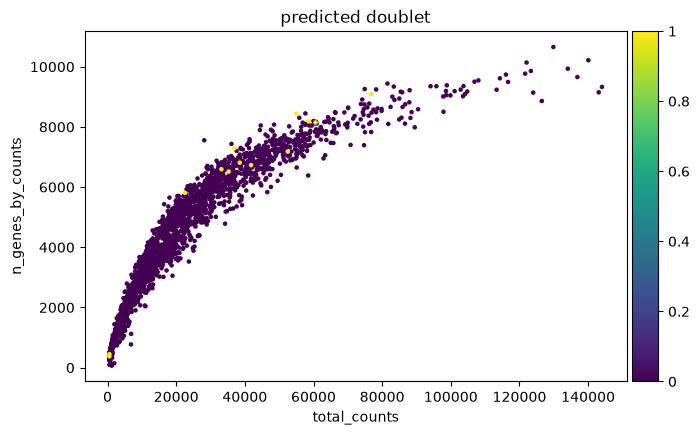

In [6]:
for k, _adata in datasets.items():
    sc.pp.scrublet(_adata)
    sc.pl.scatter(
        _adata, x="total_counts", y="n_genes_by_counts", color="predicted_doublet"
    )
    datasets[k] = _adata[~_adata.obs["predicted_doublet"], :].copy()

---
## 3. Normalization and Concatenation

In [7]:
for k, _adata in datasets.items():
    _adata.layers["counts"] = _adata.X.copy()
    sc.pp.normalize_total(_adata, target_sum=1e4)
    sc.pp.log1p(_adata)
    datasets[k] = _adata


adata = ad.concat(datasets, label="batch_id")
adata.obs_names_make_unique()

/tmp/ipykernel_3441576/783649504.py:8: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  adata = ad.concat(datasets, label="batch_id")


---
## 4. Dimensionality Reduction and Manifold Embedding
### 4-1. Feature Selection

/export/home1/okano/opt/miniforge3/envs/mamba_basalcelldemo/lib/python3.12/functools.py:912: UserWarning: Received a view of an AnnData. Making a copy.
  return dispatch(args[0].__class__)(*args, **kw)


/export/home1/okano/opt/miniforge3/envs/mamba_basalcelldemo/lib/python3.12/functools.py:912: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


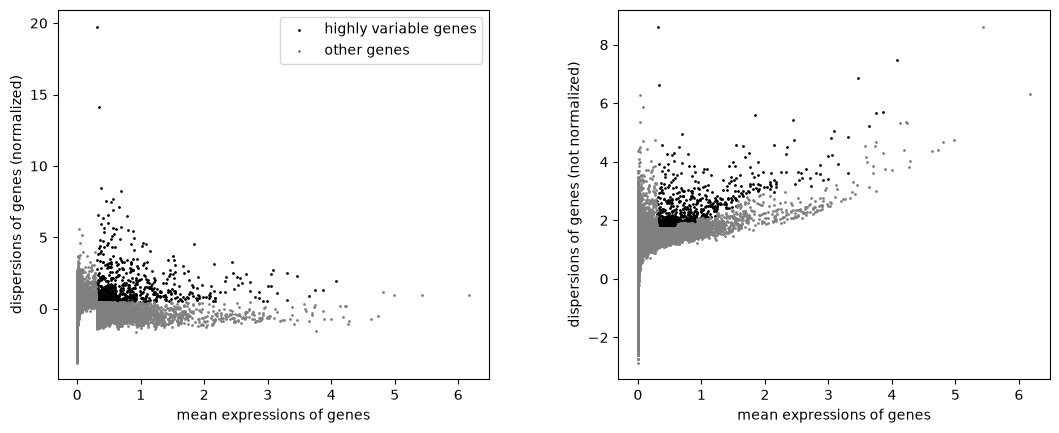

In [8]:
ad_manifold = adata.copy()

sc.pp.highly_variable_genes(ad_manifold, min_mean=0.3, max_mean=4.5, min_disp=0.5)
sc.pl.highly_variable_genes(ad_manifold, show=False)

ad_manifold = ad_manifold[:, ad_manifold.var.highly_variable]
sc.pp.scale(ad_manifold, max_value=10)

### 4-2. Dimensionality Reduction


In [9]:
sc.tl.pca(ad_manifold, svd_solver="arpack")

### 4-3. Manifold Embedding

In [10]:
sc.pp.neighbors(ad_manifold, n_pcs=50)
sc.tl.umap(ad_manifold)

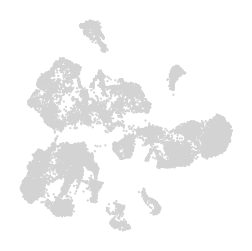

In [11]:
fig, ax = plt.subplots(figsize=(3, 3))

sc.pl.umap(ad_manifold, ax=ax, size=10, show=False)
ax.axis("off");

In [12]:
transfer_embedding_info(adata_source=ad_manifold, adata_target=adata, overwrite=True)
del ad_manifold

---
## 5. Clustering

In [13]:
sc.tl.leiden(adata, resolution=1)

/tmp/ipykernel_3441576/1886685787.py:1: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata, resolution=1)


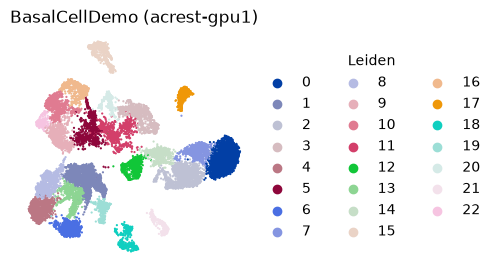

In [14]:
fig, ax = plt.subplots(figsize=(3, 3))

sc.pl.umap(adata, ax=ax, size=10, show=False, color="leiden")
ax.axis("off")
ax.set(title=f"BasalCellDemo ({ENV_SUFFIX})")
ax.legend(
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    title="Leiden",
    frameon=False,
    ncols=math.ceil(adata.obs["leiden"].nunique() / 10),
)

fig.savefig(OUTPUT_DIR / f"gbm_umap_{ENV_SUFFIX}.pdf", **kwarg_savefig)

---
## 6. Execution Environment Details

In [15]:
%%bash
bash .rep_exe_env.sh

Execution Environment

Timestamp (UTC):         2026-09-29T20:19:50Z


Hostname:                acrest-gpu1


FQDN:                    acrest-gpu1


OS:                      Ubuntu 22.04.5 LTS


...

System memory:           503.5 GiB


System vendor:           TYAN


System model:            B7122T75V8E4HR-2T-N


GPU(s):                  NVIDIA GeForce RTX 4090, 24564 MiB, 595.80;NVIDIA GeForce RTX 4090, 24564 M

iB, 595.80
